# Student Performance Analysis

This notebook explores the student dataset, creates a simple success label from the exam score, and reviews the main factors linked to performance.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df = pd.read_csv(r"student_dataset/student_failure/train.csv")



print(df.shape)     # number of rows / columns
print(df.columns)   # column names
df.head()


(630000, 15)
Index(['id', 'age', 'genre', 'diplôme', 'heures_etude', 'assiduité_classe',
       'accès_internet', 'heures_sommeil', 'qualité_sommeil', 'méthode_etude',
       'évaluation_établissement', 'difficulté_examen', 'score_examen',
       'heures_fête', 'taille_etudiant'],
      dtype='str')


,id,age,genre,diplôme,heures_etude,assiduité_classe,accès_internet,heures_sommeil,qualité_sommeil,méthode_etude,évaluation_établissement,difficulté_examen,score_examen,heures_fête,taille_etudiant
0,0,21,male,Computer Science,7.91,98.8,NaN,4.9,average,online videos,low,easy,75.02,5,1.91
1,1,18,female,Law,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,49.03,4,1.89
2,2,20,female,Computer Science,4.68,92.6,NaN,5.8,poor,coaching,high,moderate,100.00,4,1.72
3,3,19,male,Computer Science,2.00,49.5,yes,8.3,average,group study,high,moderate,63.90,4,1.51
4,4,23,female,Business Management,7.65,86.9,yes,9.6,good,self-study,high,easy,100.00,2,1.94


## Data Cleaning

We first create a target variable from the exam score so the analysis can compare students in the fail, risk, and pass groups.


In [15]:
def categorize(score):
    if score < 50:
        return "fail"
    elif score <= 60:
        return "risk"
    else:
        return "pass"

df["target"] = df["score_examen"].apply(categorize)
df["target"].value_counts()

target
pass    358085
fail    161083
risk    110832
Name: count, dtype: int64

## Exploratory Data Analysis

The next plots summarize the target classes and the most relevant numeric variables.


In [16]:
ids = df["id"]

df = df.drop(columns=["id"])
X = df.drop(columns=["score_examen", "target"])
y = df["target"]

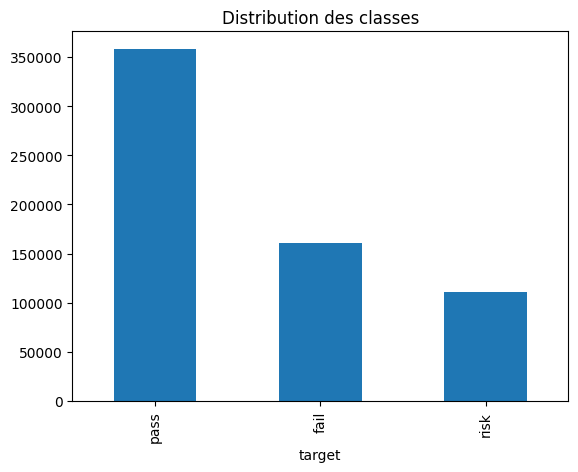

In [ ]:
# Class distribution
df["target"].value_counts().plot(kind="bar")
plt.title("Class distribution")
plt.show()

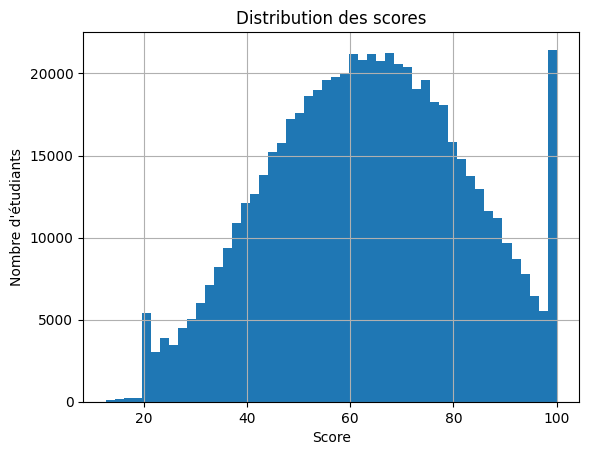

In [ ]:
# Score distribution

df["score_examen"].hist(bins=50)
plt.title("Distribution des scores")
plt.xlabel("Score")
plt.ylabel("Number of students")
plt.show()

### Study Hours and Exam Score

This section checks whether more study time is associated with better results.


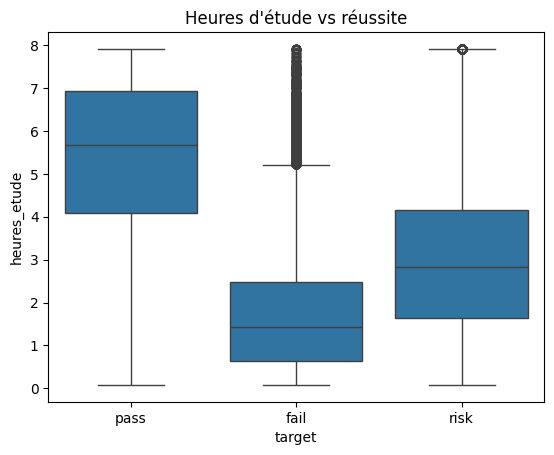

In [ ]:
import seaborn as sns

sns.boxplot(x="target", y="heures_etude", data=df)
plt.title("Study hours vs success")
plt.show()

The scatter and regression plot make the trend easier to interpret: study hours are positively related to exam score, but they do not explain everything on their own.


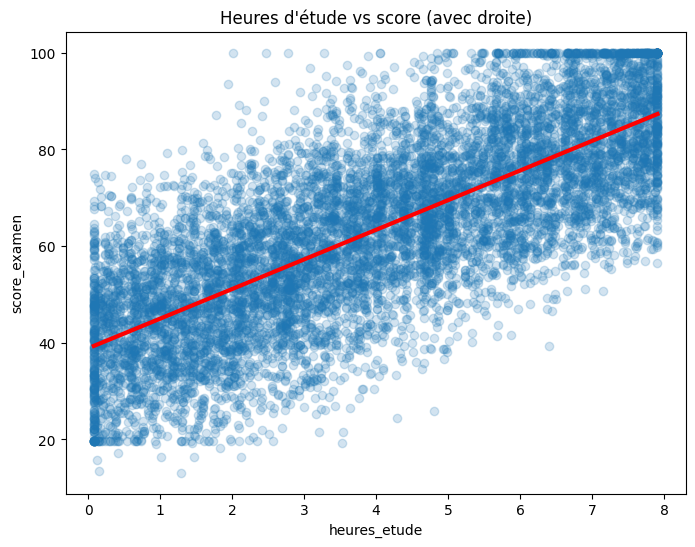

0.7576477087851184


In [ ]:

sample = df.sample(10000)

plt.figure(figsize=(8,6))

sns.regplot(
    x="heures_etude",
    y="score_examen",
    data=sample,
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "red", "linewidth": 3}
)

plt.title("Study hours vs score (with regression line)")
plt.show()

print(df["heures_etude"].corr(df["score_examen"]))

# Class attendance vs success

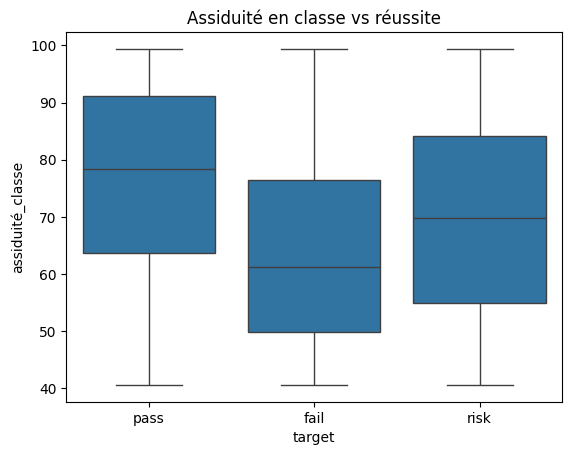

In [ ]:
# Boxplot: class attendance vs target
sns.boxplot(x="target", y="assiduité_classe", data=df)
plt.title("Class attendance vs success")
plt.show()


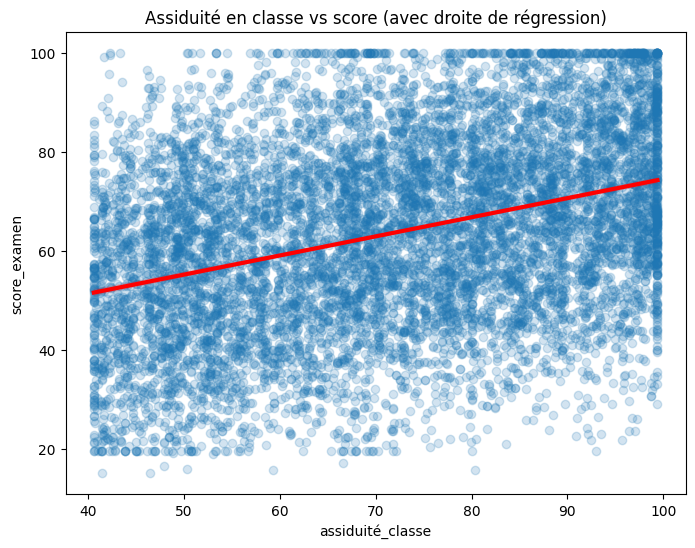

0.35945169608239697


In [ ]:
# Regression plot: class attendance vs score_examen
sample = df.sample(10000)

plt.figure(figsize=(8, 6))
sns.regplot(
    x="assiduité_classe",
    y="score_examen",
    data=sample,
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "red", "linewidth": 3}
)
plt.title("Class attendance vs score (with regression line)")
plt.show()

print(df["assiduité_classe"].corr(df["score_examen"]))


# Gender vs success

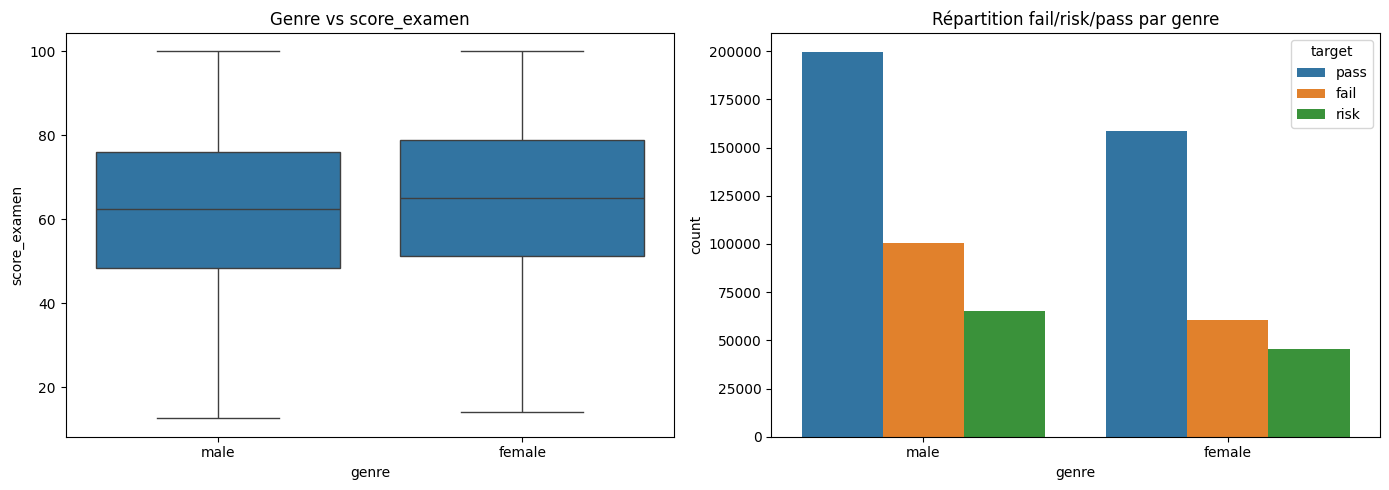

genre
female    65.036548
male      62.228632
Name: score_examen, dtype: float64


In [ ]:
# Distribution of classes (fail/risk/pass) by gender
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: gender vs score_examen
sns.boxplot(x="genre", y="score_examen", data=df, ax=axes[0])
axes[0].set_title("Genre vs score_examen")

# Countplot: class distribution by gender
sns.countplot(x="genre", hue="target", data=df, ax=axes[1])
axes[1].set_title("Fail/risk/pass distribution by gender")

plt.tight_layout()
plt.show()

print(df.groupby("genre")["score_examen"].mean())


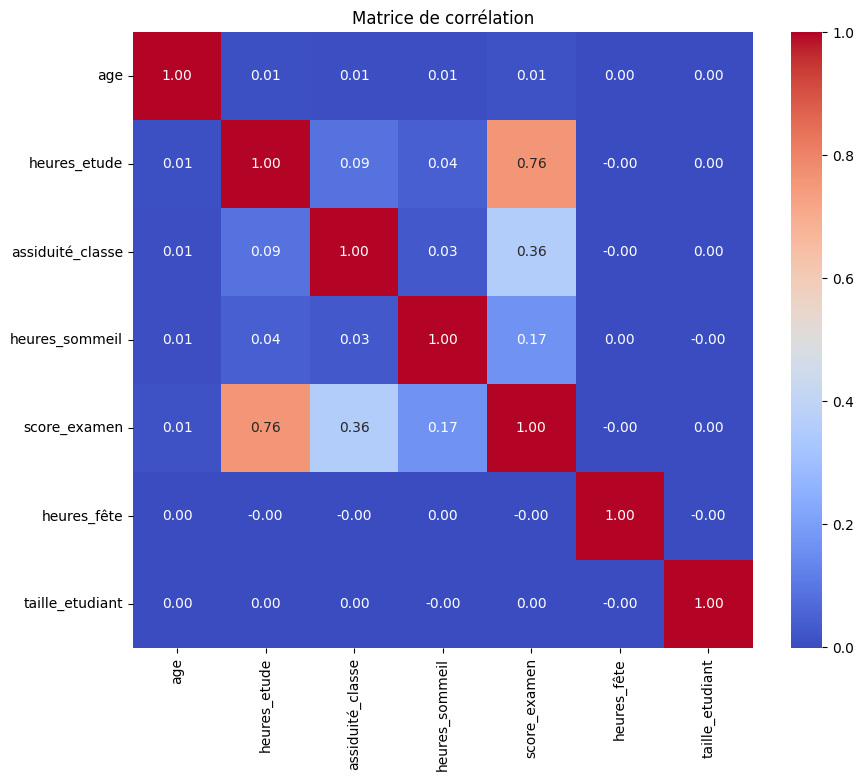

In [ ]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix")
plt.show()

C:\Users\felix\AppData\Local\Temp\ipykernel_61336\1115383047.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_ml.select_dtypes(include="object").columns



Types après encoding :
age                                  int64
genre                                int64
heures_etude                       float64
assiduité_classe                   float64
accès_internet                     float64
heures_sommeil                     float64
qualité_sommeil                      int64
évaluation_établissement             int64
difficulté_examen                    int64
score_examen                       float64
heures_fête                          int64
taille_etudiant                    float64
diplôme_Business Administration       bool
diplôme_Business Management           bool
diplôme_Computer Science              bool
diplôme_Engineering                   bool
diplôme_Law                           bool
diplôme_Marketing                     bool
méthode_etude_group study             bool
méthode_etude_mixed                   bool
méthode_etude_online videos           bool
méthode_etude_self-study              bool
méthode_etude_unknown         

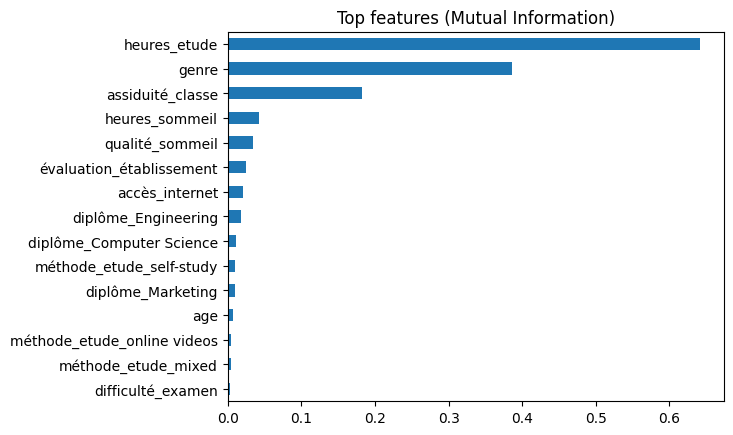

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1. LOAD
# -------------------------
df = pd.read_csv(r"student_dataset/student_failure/train.csv")

# -------------------------
# 2. COPY
# -------------------------
df_ml = df.copy()

# -------------------------
# 3. DROP ID
# -------------------------
df_ml = df_ml.drop(columns=["id"])

# -------------------------
# 4. REMOVE DUPLICATES
# -------------------------
n_before = len(df_ml)
df_ml = df_ml.drop_duplicates()
print(f"Duplicates removed: {n_before - len(df_ml)} ({len(df_ml)} rows left)")

# -------------------------
# 5. HANDLE NaN VALUES (clean)
# -------------------------

# numeric -> mean
num_cols = df_ml.select_dtypes(include=np.number).columns
df_ml[num_cols] = df_ml[num_cols].fillna(df_ml[num_cols].mean())

# categorical -> "unknown"


In [ ]:
from sklearn.feature_selection import mutual_info_regression

X = df_ml.drop(columns=["score_examen"])
y = df_ml["score_examen"]

mi = mutual_info_regression(X, y)

mi = pd.Series(mi, index=X.columns).sort_values(ascending=False)

print(mi.head(15))

In [ ]:
from sklearn.feature_selection import mutual_info_regression

mi_sleep = mutual_info_regression(
    df_ml[["heures_sommeil"]],
    df_ml["qualité_sommeil"]
)

print(mi_sleep)

#df_ml["sleep_interaction"] = df_ml["heures_sommeil"] * df_ml["qualité_sommeil"]
#mi = mutual_info_regression(X, y)
#print(mi)

# useful heatmap

In [ ]:
mi = pd.Series(mi, index=X.columns).sort_values(ascending=False)

important_features = mi[mi > 0.01].index.tolist()

# add target column
important_features.append("score_examen")

corr = df_ml[important_features].corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Correlation between important variables")
plt.show()